# Member 6 — Feature Selection & Dimension Reduction (PCA)

**Technique:** Select informative features (`SelectKBest`) and reduce dimensionality with **PCA**.

## Why this dataset needs it
Engineered histograms are correlated and moderately wide. PCA compresses signal for visualization and can reduce overfitting for small-to-medium image sets.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve Group_Deliverable root whether cwd is notebooks/ or deliverable root
HERE = Path.cwd().resolve()
ROOT = None
for p in (HERE, *HERE.parents):
    if (p / "src" / "preprocess_utils.py").exists():
        ROOT = p
        break
    if (p / "Group_Deliverable" / "src" / "preprocess_utils.py").exists():
        ROOT = p / "Group_Deliverable"
        break
if ROOT is None:
    raise FileNotFoundError("Run from progress/Group_Deliverable or its notebooks/ folder.")

sys.path.insert(0, str(ROOT / "src"))
from preprocess_utils import (
    SEED, SOURCE_URL, DOI, FOLDERS, CLASSES, paths,
    inventory_table, discover_images, audit_images,
    remove_exact_duplicates, iqr_mask, extract_feature_matrix, read_rgb,
    stratified_sample, draw_process_flow,
)

P = paths(ROOT)
RAW, VIZ, OUT, LOGS = P["raw"], P["viz"], P["outputs"], P["logs"]
for d in (VIZ, OUT, LOGS):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(SEED)
PIPELINE_STEPS = [
    "1 Missing\ndata",
    "2 Categorical\nencoding",
    "3 Outlier /\nduplicate",
    "4 Feature\nengineering",
    "5 Scaling",
    "6 SelectKBest\n+ PCA",
]
print("Deliverable root:", ROOT)
print("Raw data:", RAW)
print("Dataset:", SOURCE_URL, "| DOI:", DOI)


Deliverable root: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable
Raw data: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable\data\raw
Dataset: https://ieee-dataport.org/open-access/leaves-indias-most-famous-basil-plant-leaves-quality-dataset | DOI: 10.21227/a4f6-4413


## 0. Process diagram — where this step sits in the pipeline


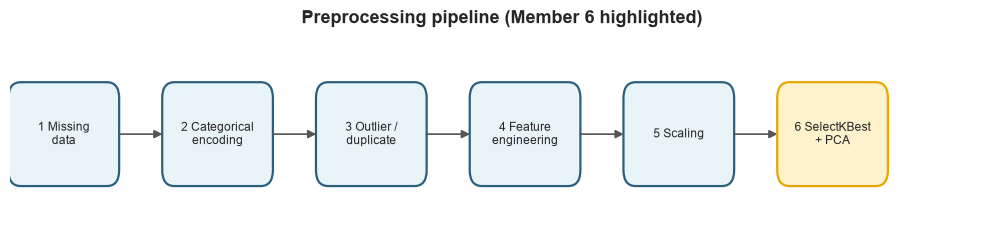

In [2]:
fig, _ = draw_process_flow(
    PIPELINE_STEPS,
    title="Preprocessing pipeline (Member 6 highlighted)",
    highlight=5,
)
fig.savefig(VIZ / "m6_process_flow.png", dpi=150, bbox_inches="tight")
plt.show()


In [3]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler

npz_path = OUT / "m4_scaled_features.npz"
if npz_path.exists():
    data = np.load(npz_path, allow_pickle=True)
    X_raw, y = data["X_raw"], data["y"]
    print("Loaded Member 4 features:", X_raw.shape)
else:
    meta_path = OUT / "m3_cleaned_no_outliers.csv"
    meta = pd.read_csv(meta_path) if meta_path.exists() else audit_images(RAW)[0]
    sample = stratified_sample(meta, 120)
    X_raw, y, _ = extract_feature_matrix(RAW, sample)
    print("Computed features:", X_raw.shape)

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_std = StandardScaler().fit_transform(X_raw)
k = min(20, X_std.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
X_sel = selector.fit_transform(X_std, y_enc)
print(f"SelectKBest kept {k} / {X_std.shape[1]} features")

pca = PCA(n_components=min(10, X_sel.shape[1]), random_state=SEED)
X_pca = pca.fit_transform(X_sel)
print("Explained variance ratio (first 5):", np.round(pca.explained_variance_ratio_[:5], 4))
print("Cumulative variance (all kept PCs):", float(pca.explained_variance_ratio_.sum()))

np.savez_compressed(
    OUT / "m6_selected_pca_features.npz",
    X_selected=X_sel,
    X_pca=X_pca,
    y=y,
    explained_variance_ratio=pca.explained_variance_ratio_,
)
pd.DataFrame({
    "pc": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_),
}).to_csv(OUT / "m6_pca_variance.csv", index=False)


Loaded Member 4 features: (240, 60)
SelectKBest kept 20 / 60 features
Explained variance ratio (first 5): [0.7018 0.0798 0.0538 0.0468 0.0353]
Cumulative variance (all kept PCs): 0.9870310425758362


## EDA visualizations — F-scores, PCA variance bars & scatter


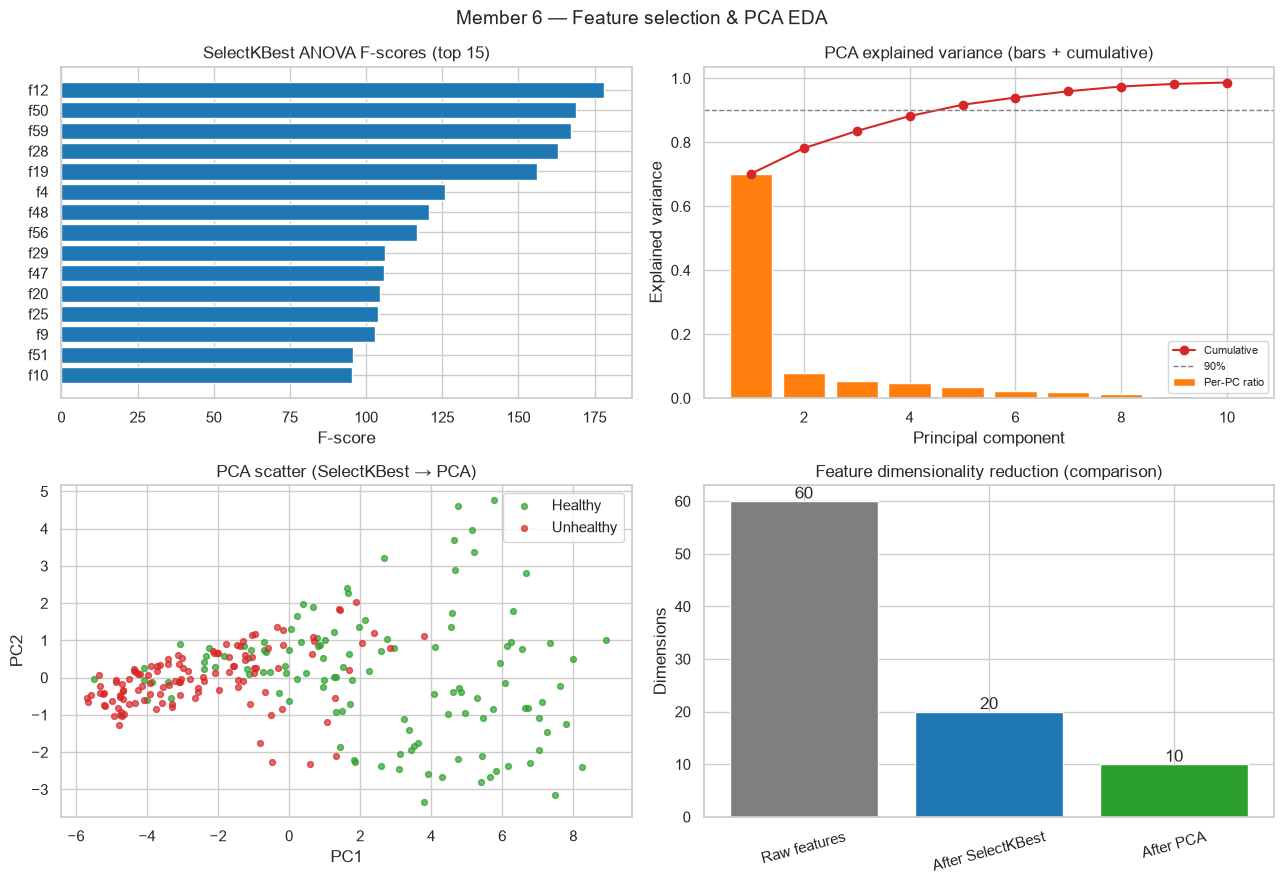

Interpretation: if Healthy/Unhealthy form soft clusters in PC1–PC2, engineered color features carry separable signal after selection/reduction.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# SelectKBest F-scores (top features)
scores = selector.scores_
top_idx = np.argsort(scores)[::-1][:15]
axes[0, 0].barh([f"f{i}" for i in top_idx[::-1]], scores[top_idx][::-1], color="#1f77b4")
axes[0, 0].set_title("SelectKBest ANOVA F-scores (top 15)")
axes[0, 0].set_xlabel("F-score")

# PCA explained variance — bar + cumulative line
pcs = np.arange(1, len(pca.explained_variance_ratio_) + 1)
axes[0, 1].bar(pcs, pca.explained_variance_ratio_, color="#ff7f0e", label="Per-PC ratio")
axes[0, 1].plot(pcs, np.cumsum(pca.explained_variance_ratio_), marker="o", color="#d62728", label="Cumulative")
axes[0, 1].axhline(0.9, color="gray", ls="--", lw=1, label="90%")
axes[0, 1].set_xlabel("Principal component")
axes[0, 1].set_ylabel("Explained variance")
axes[0, 1].set_title("PCA explained variance (bars + cumulative)")
axes[0, 1].legend(fontsize=8)

# 2D scatter
for cls, color in zip(CLASSES, ["#2ca02c", "#d62728"]):
    mask = y == cls
    axes[1, 0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=18, alpha=0.7, label=cls, c=color)
axes[1, 0].set_xlabel("PC1")
axes[1, 0].set_ylabel("PC2")
axes[1, 0].set_title("PCA scatter (SelectKBest → PCA)")
axes[1, 0].legend()

# Dimensionality funnel comparison bars
dims = ["Raw features", "After SelectKBest", "After PCA"]
dim_vals = [X_std.shape[1], X_sel.shape[1], X_pca.shape[1]]
axes[1, 1].bar(dims, dim_vals, color=["#7f7f7f", "#1f77b4", "#2ca02c"])
axes[1, 1].set_title("Feature dimensionality reduction (comparison)")
axes[1, 1].set_ylabel("Dimensions")
axes[1, 1].tick_params(axis="x", rotation=15)
for i, v in enumerate(dim_vals):
    axes[1, 1].text(i, v + 0.5, str(v), ha="center")

fig.suptitle("Member 6 — Feature selection & PCA EDA", fontsize=14)
fig.tight_layout()
fig.savefig(VIZ / "m6_pca_variance_and_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Interpretation: if Healthy/Unhealthy form soft clusters in PC1–PC2, engineered color features carry separable signal after selection/reduction.")
